# Proyek Klasifikasi Gambar: Garbage Image Classification
- **Nama:** Rifky Yudistiansyah
- **Email:** rifkyyudistiansyah@gmail.com
- **ID Dicoding:** rifky_yudistiansyah

## Import Semua Packages/Library yang Digunakan

In [2]:
!pip install -q split-folders

In [3]:
import os, shutil, random, glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import splitfolders
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
!pip install -q kaggle

## Data Preparation

### Data Loading

In [17]:
from google.colab import files
files.upload()

{}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d sumn2u/garbage-classification-v2
!unzip -q garbage-classification-v2.zip

Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT
 99% 736M/744M [00:03<00:00, 145MB/s] 
100% 744M/744M [00:03<00:00, 217MB/s]


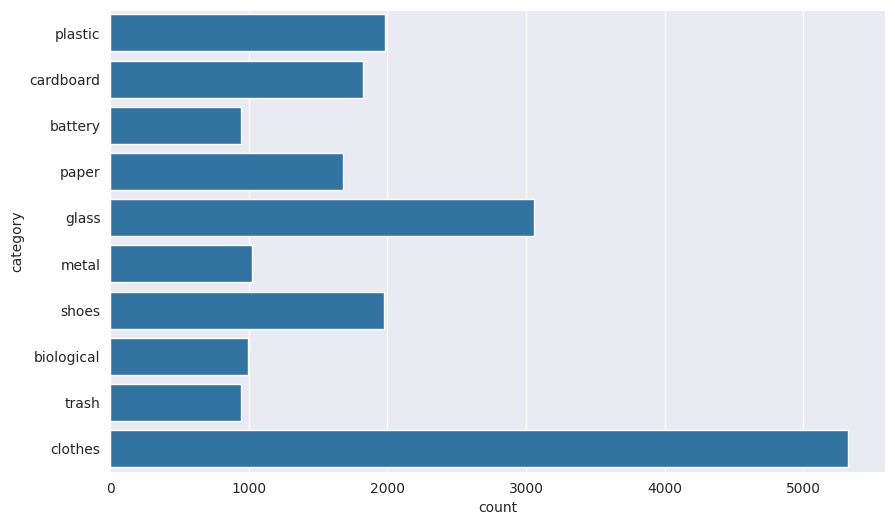

In [8]:
raw_path = '/content/garbage-dataset'

full_path = []
category = []
file_name = []

for path, subdir, files in os.walk(raw_path):
  for name in files:
    file_name.append(name)
    full_path.append(os.path.join(path, name))
    category.append(path.split('/')[-1])

data = pd.DataFrame({'full_path': full_path,
                    'category': category,
                    'file_name': file_name})

plt.figure(figsize=(10, 6))
sns.set_style('darkgrid')
sns.countplot(data['category'])
plt.show()

### Data Preprocessing

In [9]:
raw_path = "/content/garbage-dataset"
balanced_path = "/content/submission-garbage/balanced_all/garbage-dataset"
split_path = "/content/submission-garbage/split_data/garbage-dataset"
target_count = 2500

if os.path.exists(balanced_path):
    shutil.rmtree(balanced_path)
os.makedirs(balanced_path)

augmentor = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.1,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

for class_name in os.listdir(raw_path):
    src_folder = os.path.join(raw_path, class_name)
    dst_folder = os.path.join(balanced_path, class_name)
    os.makedirs(dst_folder, exist_ok=True)

    images = os.listdir(src_folder)

    # Salin semua gambar
    for img_name in images:
        src_path = os.path.join(src_folder, img_name)
        if os.path.isfile(src_path): # Check if it's a file before copying
            shutil.copy(src_path, os.path.join(dst_folder, img_name))

    # Potong jika lebih dari target
    current_images = os.listdir(dst_folder)
    if len(current_images) > target_count:
        excess = len(current_images) - target_count
        to_delete = random.sample(current_images, excess)
        for img_name in to_delete:
            os.remove(os.path.join(dst_folder, img_name))

    # Augmentasi jika kurang dari target
    current_images = os.listdir(dst_folder)
    needed = target_count - len(current_images)
    if needed > 0:
        src_files = [f for f in os.listdir(src_folder) if os.path.isfile(os.path.join(src_folder, f))]
        if not src_files:
            print(f"Skipping augmentation for {class_name} as no files found in source folder.")
            continue

        while needed > 0:
            img_name = random.choice(src_files)
            img_path = os.path.join(src_folder, img_name)
            img = load_img(img_path, target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)
            for batch in augmentor.flow(x, batch_size=1):
                new_name = f"aug_{random.randint(0,99999)}_{img_name}"
                tf.keras.utils.save_img(os.path.join(dst_folder, new_name), batch[0])
                needed -= 1
                break

print("Semua kelas sudah balance menjadi 2500 gambar")

Semua kelas sudah balance menjadi 2500 gambar


#### Split Dataset

Copying files: 25000 files [00:03, 6745.07 files/s]


Data split ke: /content/submission-garbage/split_data/garbage-dataset
Found 17500 images belonging to 10 classes.
Found 3750 images belonging to 10 classes.
Found 3750 images belonging to 10 classes.

Jumlah gambar per kelas di TRAIN:
🔹 battery: 1750 gambar
🔹 biological: 1750 gambar
🔹 cardboard: 1750 gambar
🔹 clothes: 1750 gambar
🔹 glass: 1750 gambar
🔹 metal: 1750 gambar
🔹 paper: 1750 gambar
🔹 plastic: 1750 gambar
🔹 shoes: 1750 gambar
🔹 trash: 1750 gambar

Jumlah gambar per kelas di VAL:
🔹 battery: 375 gambar
🔹 biological: 375 gambar
🔹 cardboard: 375 gambar
🔹 clothes: 375 gambar
🔹 glass: 375 gambar
🔹 metal: 375 gambar
🔹 paper: 375 gambar
🔹 plastic: 375 gambar
🔹 shoes: 375 gambar
🔹 trash: 375 gambar

Jumlah gambar per kelas di TEST:
🔹 battery: 375 gambar
🔹 biological: 375 gambar
🔹 cardboard: 375 gambar
🔹 clothes: 375 gambar
🔹 glass: 375 gambar
🔹 metal: 375 gambar
🔹 paper: 375 gambar
🔹 plastic: 375 gambar
🔹 shoes: 375 gambar
🔹 trash: 375 gambar


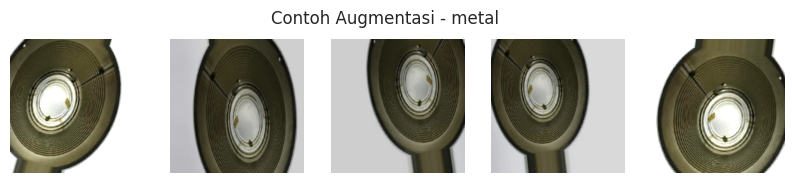

In [10]:
if os.path.exists(split_path):
    shutil.rmtree(split_path)
splitfolders.ratio(balanced_path, output=split_path, seed=42, ratio=(.7, .15, .15))
print("Data split ke:", split_path)

# Generator
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(split_path, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(split_path, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(split_path, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# Jumlah gambar per kelas
def show_counts(path, label):
    print(f"\nJumlah gambar per kelas di {label.upper()}:")
    for cls in sorted(os.listdir(path)):
        n = len(os.listdir(os.path.join(path, cls)))
        print(f"🔹 {cls}: {n} gambar")

show_counts(os.path.join(split_path, "train"), "train")
show_counts(os.path.join(split_path, "val"), "val")
show_counts(os.path.join(split_path, "test"), "test")

# Contoh augmentasi
sample_class = random.choice(list(train_gen.class_indices.keys()))
sample_dir = os.path.join(split_path, "train", sample_class)
sample_img_path = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))

img = load_img(sample_img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

plt.figure(figsize=(10,2))
for i, batch in zip(range(5), augmentor.flow(x, batch_size=1)):
    plt.subplot(1, 5, i+1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis('off')
plt.suptitle(f"Contoh Augmentasi - {sample_class}")
plt.show()

## Modelling

In [11]:
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

head_model = Sequential([
    Input(shape=base_model.output_shape[1:]),
    Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

x = base_model.output
outputs = head_model(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1)
]

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,503,690 (20.99 MB)

 Trainable params: 4,772,106 (18.20 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


547/547 ━━━━━━━━━━━━━━━━━━━━ 109s 153ms/step - accuracy: 0.6021 - loss: 1.3459 - val_accuracy: 0.8315 - val_loss: 0.5946 - learning_rate: 1.0000e-04
Epoch 2/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.8923 - loss: 0.3525 - val_accuracy: 0.8920 - val_loss: 0.3896 - learning_rate: 1.0000e-04
Epoch 3/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.9370 - loss: 0.2046 - val_accuracy: 0.9197 - val_loss: 0.3237 - learning_rate: 1.0000e-04
Epoch 4/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9588 - loss: 0.1318 - val_accuracy: 0.9363 - val_loss: 0.2656 - learning_rate: 1.0000e-04
Epoch 5/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - accuracy: 0.9749 - loss: 0.0827 - val_accuracy: 0.9224 - val_loss: 0.3544 - learning_rate: 1.0000e-04
Epoch 6/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9785 - loss: 0.0703 - val_accuracy: 0.9331 - val_loss: 0.3457 - learning_rate: 1.0000e-04
Epoch 7/25
547/547 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - accur

## Evaluasi dan Visualisasi

118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9752 - loss: 0.1978

Akurasi Data Test: 95.73%
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step

Classification Report:
              precision    recall  f1-score   support

     battery       0.98      0.99      0.99       375
  biological       0.99      0.99      0.99       375
   cardboard       0.95      0.96      0.96       375
     clothes       0.99      0.98      0.98       375
       glass       0.91      0.94      0.93       375
       metal       0.93      0.97      0.95       375
       paper       0.94      0.94      0.94       375
     plastic       0.95      0.88      0.92       375
       shoes       0.98      0.98      0.98       375
       trash       0.95      0.94      0.95       375

    accuracy                           0.96      3750
   macro avg       0.96      0.96      0.96      3750
weighted avg       0.96      0.96      0.96      3750



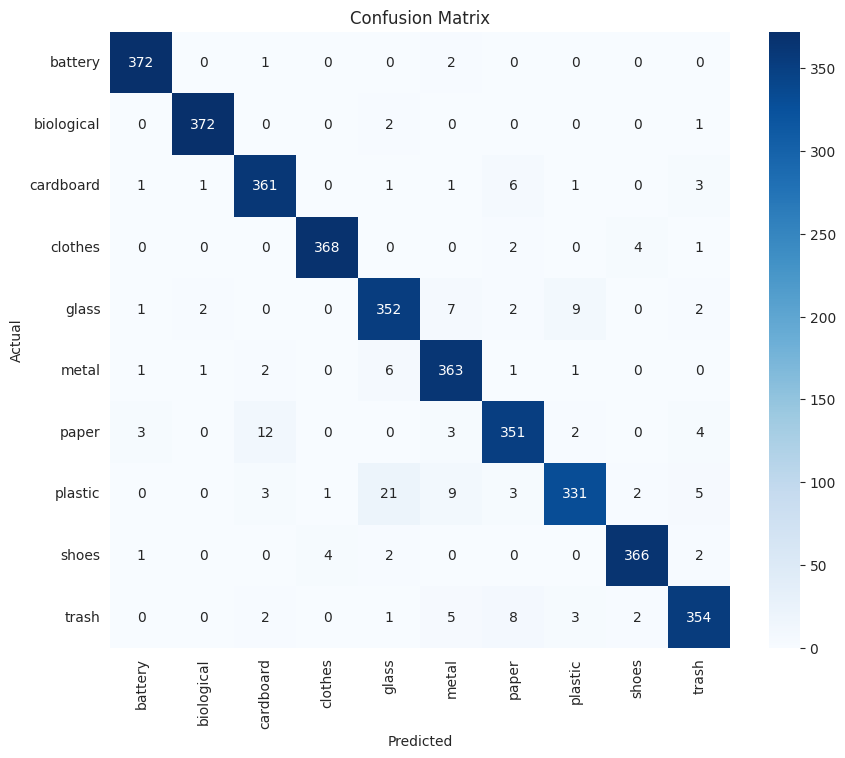

In [13]:
loss_test, acc_test = model.evaluate(test_gen)
print(f"\nAkurasi Data Test: {acc_test * 100:.2f}%")

y_pred = np.argmax(model.predict(test_gen), axis=1)
class_names = [cls for cls in test_gen.class_indices.keys() if cls != 'balanced_all']
print("\nClassification Report:")
print(classification_report(test_gen.classes, y_pred, target_names=class_names))

cm = confusion_matrix(test_gen.classes, y_pred)
cm_labels = [cls for cls in test_gen.class_indices.keys() if cls != 'balanced_all']
cm_df = pd.DataFrame(cm, index=cm_labels, columns=cm_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

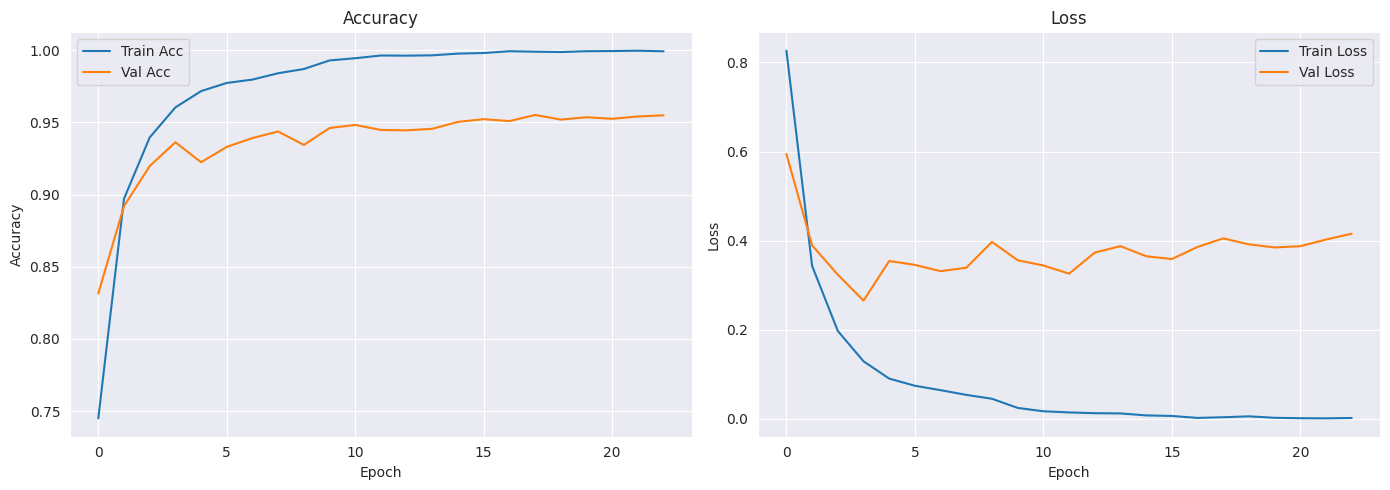


Ringkasan Akurasi:
🔹 Training Tertinggi   : 99.97%
🔹 Validation Tertinggi : 95.52%
🔹 Akurasi Test         : 95.73%


In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nRingkasan Akurasi:")
print(f"🔹 Training Tertinggi   : {max(history.history['accuracy'])*100:.2f}%")
print(f"🔹 Validation Tertinggi : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"🔹 Akurasi Test         : {acc_test * 100:.2f}%")

## Konversi Model

In [15]:
model.save('best_model.h5')

In [ ]:
# Menyimpan model dalam format SavedModel
export_dir = 'saved_model/'
tf.saved_model.save(model, export_dir)

# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('vegs.tflite')
tflite_model_file.write_bytes(tflite_model)

In [ ]:
h5_model_path = 'best_model.h5'
saved_model_path = 'saved_model_format'

print(f"Memuat model dari: {h5_model_path}")
model = tf.keras.models.load_model(h5_model_path, compile=False)

print(f"Menyimpan model ke format SavedModel di: {saved_model_path}")
model.export(saved_model_path)

print(f"Konversi ke SavedModel selesai.")

Memuat model dari: best_model.h5
Menyimpan model ke format SavedModel di: saved_model_format
Saved artifact at 'saved_model_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136802714613328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714606800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714613520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714612368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714613712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714613136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714607184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714612560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802714612176: TensorSpec(shape=(), dtype=tf.resour

In [ ]:
h5_model_path = 'best_model.h5'
tflite_model_path = 'model.tflite'

print(f"Memuat model dari: {h5_model_path}")
model = tf.keras.models.load_model(h5_model_path, compile=False)

print(f"Mengonversi model ke format TF-Lite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

print(f"Menyimpan model ke: {tflite_model_path}")
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Konversi ke TF-Lite selesai.")

Memuat model dari: best_model.h5
Mengonversi model ke format TF-Lite...
Saved artifact at '/tmp/tmp7fd2410d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136802006282128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006285008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006281936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006282704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006281744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006282320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006284240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006283280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006282896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136802006280

In [ ]:
class_names = list(train_gen.class_indices.keys())

with open("label.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("label.txt berhasil dibuat dengan isi:")
print("\n".join(class_names))

label.txt berhasil dibuat dengan isi:
battery
biological
cardboard
clothes
glass
metal
paper
plastic
shoes
trash


In [ ]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.38.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.9.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.


In [ ]:
!tensorflowjs_converter --input_format=keras best_model.h5 tfjs_model

2025-09-28 11:37:28.328765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759059448.348369    7822 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759059448.355096    7822 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759059448.372709    7822 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759059448.372735    7822 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759059448.372739    7822 computation_placer.cc:177] computation placer alr

## Inference

Class labels terdeteksi: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


Saving botol.jpg to botol.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


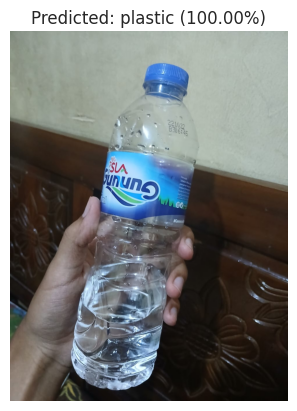

In [18]:
model = load_model('best_model.h5')

train_dir = os.path.join(split_path, "train")
class_labels = sorted(os.listdir(train_dir))

print("Class labels terdeteksi:", class_labels)

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.2f}%)")
    plt.show()

In [ ]:
!pip install pipreqs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.3 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=4310c658d7a0ce07b323f9d6f5b4181ab0e08726a2d25c7d5a8308d3327de880
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.12.3 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pipreqs "/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir" --scan-notebooks --force

In [ ]:
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/saved_model', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/tflite', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/tfjs_model', exist_ok=True)

In [ ]:
shutil.move('saved_model', '/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/saved_model')

shutil.move('model.tflite', '/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/tflite/model.tflite')
shutil.move('label.txt', '/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/tflite/label.txt')

tfjs_files = os.listdir('tfjs_model')
for file_name in tfjs_files:
    shutil.move(os.path.join('tfjs_model', file_name), '/content/drive/MyDrive/Colab Notebooks/Deep-Learning-Submission-Akhir/tfjs_model/')